In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import re


# --- 1. Robust Data Cleaner ---
def clean_and_prep(filename):
    # Load
    df = pd.read_csv(filename, sep=';', encoding='latin-1')
    
    # 1. EXPLICIT FILTERING (Drop Financial Sector)
    df = df[df['SECTOR'] != 'ACTIVIDADES FINANCIERAS Y DE SEGUROS'].copy()
    
    # 2. Standardize Column Names
    def clean_name(name):
        return re.sub(r'[^a-zA-Z0-9_]', '_', name.strip().lower()).strip('_')
    
    df.columns = [clean_name(c) for c in df.columns]
    
    # 3. Date Engineering
    date_col = [c for c in df.columns if 'fecha' in c][0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df = df.dropna(subset=[date_col]) # Drop rows with bad dates immediately
    df['quarter'] = df[date_col].dt.to_period('Q').astype(str)
    
    # 4. Target Scaling (CRITICAL FOR CONVERGENCE)
    # Working in "Millions of USD" prevents overflow errors in the Log Link
    target = 'monto_otorgado'
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df = df[df[target] > 0] # GLM Log link requires > 0
    df['monto_millions'] = df[target] / 1_000_000  # Scale target
    
    # 5. Categorical reduction
    for col in ['provincia', 'sector']:
        if col in df.columns:
            top_n = df[col].value_counts().nlargest(6).index
            df[col] = df[col].apply(lambda x: x if x in top_n else 'other')

    # 6. Drop unused
    cols_to_drop = ['canton', 'subsector', 'actividad', 'subsistema', 'entidad', 'ruc', 'nombre', date_col, target]
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    
    # 7. One-Hot Encoding
    df_final = pd.get_dummies(df, drop_first=True, dtype=int)
    
    # 8. Sanitize Columns & Remove Duplicates
    df_final.columns = [clean_name(c) for c in df_final.columns]
    # Remove duplicate columns (fixes the Agriculture double-counting issue)
    df_final = df_final.loc[:, ~df_final.columns.duplicated()]
    
    # Remove 'NaT' columns if they sneak in
    df_final = df_final.loc[:, [c for c in df_final.columns if 'nat' not in c]]
    
    return df_final

# --- 2. Execution ---

# Run Prep
df_clean = clean_and_prep('cfn_volumencreditocontingente_2025_enero-septiembre.csv')

print(f"Refined Data Shape: {df_clean.shape}")

# Define Formula
target_col = 'monto_millions'
predictors = [c for c in df_clean.columns if c != target_col]
formula_str = f"{target_col} ~ {' + '.join(predictors)}"

print("\n--- Model 1: Inverse Gaussian (Scaled Target) ---")
try:
    # 1. Fit Inverse Gaussian
    model_ig = smf.glm(
        formula=formula_str,
        data=df_clean,
        family=sm.families.InverseGaussian(link=sm.families.links.Log())
    )
    # We use a specific method (Newton-Raphson) which is often more stable for IG
    result = model_ig.fit(method='newton') 
    
    print(result.summary())
    print(f"\nSUCCESS. Dispersion (Scale): {result.scale:.4f}")
    
except Exception as e:
    print(f"\nIG Failed ({e}). Switching to Tweedie...")
    
    # FALLBACK: Tweedie (Power 2.5 is a mix of Gamma and IG)
    # This is the industry standard "Robust GLM"
    model_tw = smf.glm(
        formula=formula_str,
        data=df_clean,
        family=sm.families.Tweedie(link=sm.families.links.Log(), var_power=2.5)
    )
    result = model_tw.fit()
    print(result.summary())

Refined Data Shape: (465, 33)

--- Model 1: Inverse Gaussian (Scaled Target) ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:         monto_millions   No. Observations:                  465
Model:                            GLM   Df Residuals:                      432
Model Family:         InverseGaussian   Df Model:                           32
Link Function:                    Log   Scale:                          3.7036
Method:                        newton   Log-Likelihood:                -170.99
Date:                Tue, 03 Feb 2026   Deviance:                       3507.5
Time:                        16:02:22   Pearson chi2:                 1.60e+03
No. Iterations:                   100   Pseudo R-squ. (CS):             0.8558
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
--------

/Users/equina/Documents/Generalized_Linear_Model_CFN/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<>:53: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3c/z87p2q816b55gkkf_05bzyhr0000gn/T/ipykernel_6787/2661550054.py:53: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].set_ylabel('$\sqrt{|Standardized Deviance Resid|}$')
/Users/equina/Documents/Generalized_Linear_Model_CFN/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:2226: RuntimeWarning: invalid value encountered in sqrt
  weights_sqrt = np.sqrt(weights)
/Users/equina/Documents/Generalized_Linear_Model_CFN/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:2197: RuntimeWarning: invalid value encountered in sqrt
  wexog = np.sqrt(weights)[:, None] * self.model.exog
/var/folders/3c/z87p2q816b55gkkf_05bzyhr0000gn/T/ipykernel_6787/2661550054.py:53: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].set_ylabel('$\sqrt{|Standardized Deviance Resid|}$')


LinAlgError: SVD did not converge

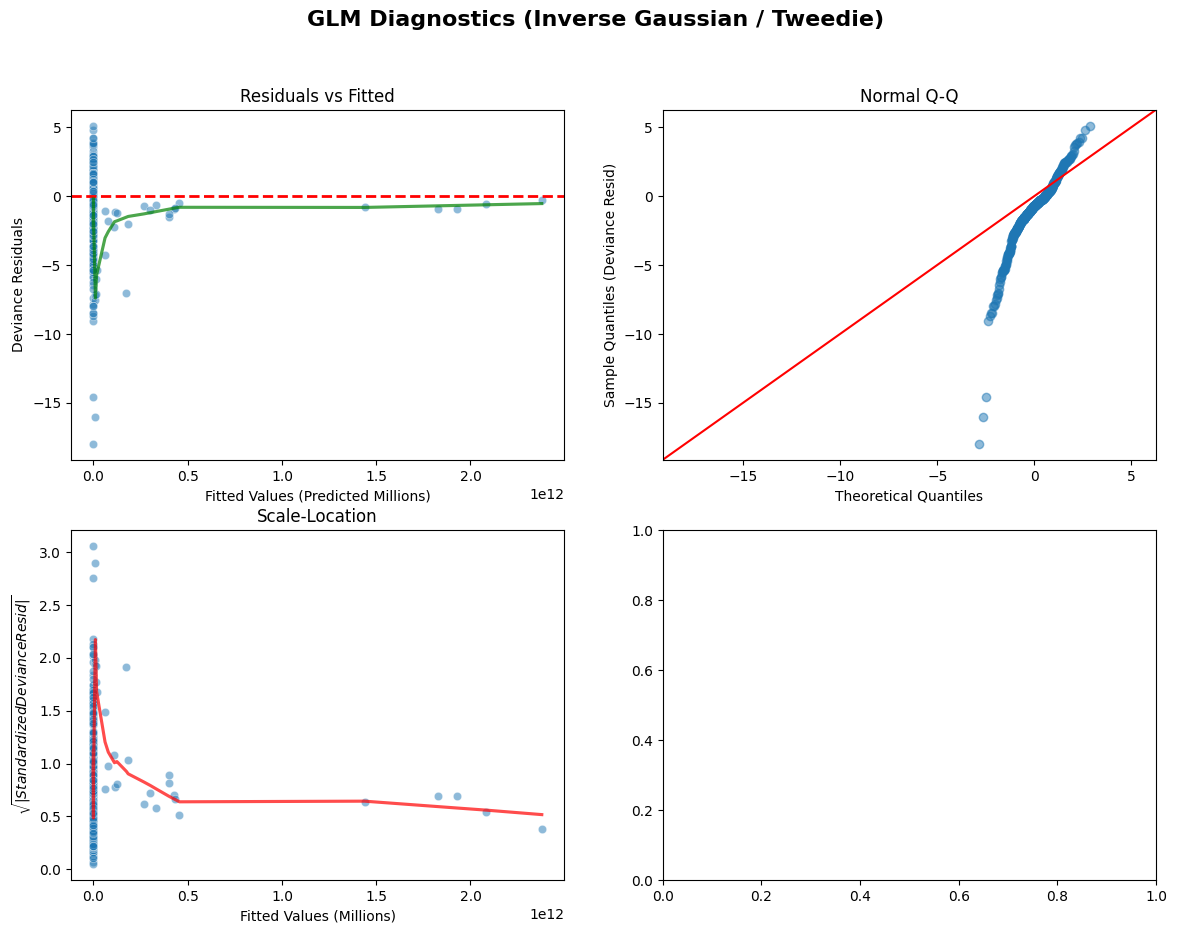

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import ProbPlot

def plot_glm_diagnostics(result_model):
    """
    Generates 4 standard diagnostic plots for GLM evaluation:
    1. Residuals vs Fitted (Linearity & Homoscedasticity)
    2. Q-Q Plot (Normality of Deviance Residuals)
    3. Scale-Location (Spread of residuals across range)
    4. Cook's Distance (Influential Outliers)
    """
    
    # 1. Extract Key Metrics
    fitted_vals = result_model.mu
    # For GLMs, Deviance Residuals are preferred over Pearson for normality checks
    resid_deviance = result_model.resid_deviance
    # Standardized Deviance Residuals
    resid_std = result_model.resid_deviance / np.sqrt(result_model.scale)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('GLM Diagnostics (Inverse Gaussian / Tweedie)', fontsize=16, fontweight='bold')

    # --- Plot 1: Residuals vs Fitted ---
    # Goal: Random scatter around 0. No "U" shapes or funnels.
    sns.scatterplot(x=fitted_vals, y=resid_deviance, ax=axes[0, 0], alpha=0.5, edgecolor='w')
    axes[0, 0].axhline(0, color='r', linestyle='--', lw=2)
    # Optional: Add a smooth loess line to detect curvature
    sns.regplot(x=fitted_vals, y=resid_deviance, scatter=False, ax=axes[0, 0], 
                lowess=True, line_kws={'color': 'green', 'alpha': 0.7})
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].set_xlabel('Fitted Values (Predicted Millions)')
    axes[0, 0].set_ylabel('Deviance Residuals')

    # --- Plot 2: Normal Q-Q Plot ---
    # Goal: Points should hug the red 45-degree line.
    QQ = ProbPlot(resid_deviance)
    QQ.qqplot(line='45', alpha=0.5, ax=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q')
    axes[0, 1].set_xlabel('Theoretical Quantiles')
    axes[0, 1].set_ylabel('Sample Quantiles (Deviance Resid)')

    # --- Plot 3: Scale-Location (Spread-Location) ---
    # Goal: Horizontal line. If it slopes up, variance increases with mean (Heteroscedasticity).
    # We use sqrt of absolute standardized residuals
    sqrt_abs_resid = np.sqrt(np.abs(resid_std))
    sns.scatterplot(x=fitted_vals, y=sqrt_abs_resid, ax=axes[1, 0], alpha=0.5, edgecolor='w')
    sns.regplot(x=fitted_vals, y=sqrt_abs_resid, scatter=False, ax=axes[1, 0], 
                lowess=True, line_kws={'color': 'red', 'alpha': 0.7})
    axes[1, 0].set_title('Scale-Location')
    axes[1, 0].set_xlabel('Fitted Values (Millions)')
    axes[1, 0].set_ylabel('$\sqrt{|Standardized Deviance Resid|}$')

    # --- Plot 4: Cook's Distance (Influence) ---
    # Goal: Identify points with high leverage that distort the model.
    influence = result_model.get_influence()
    cooks_d = influence.cooks_distance[0]
    
    # Threshold: 4/N is a common rule of thumb
    n = len(fitted_vals)
    threshold = 4/n
    
    axes[1, 1].vlines(x=np.arange(n), ymin=0, ymax=cooks_d, color='gray', alpha=0.5)
    axes[1, 1].scatter(np.arange(n), cooks_d, alpha=0.5, s=20)
    axes[1, 1].axhline(threshold, color='r', linestyle='--', label=f'Threshold (4/N = {threshold:.3f})')
    axes[1, 1].set_title("Cook's Distance (Influential Points)")
    axes[1, 1].set_xlabel('Observation Index')
    axes[1, 1].set_ylabel("Cook's Distance")
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Execute using the 'result' object from the previous step
plot_glm_diagnostics(result)